# Complete Single-Stage Run: Midpoint Geometry

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, '../../..')
sys.path.insert(0, '../..')
sys.path.insert(0, '.')

plt.style.use('../../../configurations/style.mplstyle')
datafiles           = Path('../../../datafiles')
baseline_filenames  = "../Output_files/baseline_flat_midpoint_alpha"
possible_alpha      = ["A0.5", "A1.0", "A3.0", "A5.0"]
baseline_paths      = {a : Path(f"{baseline_filenames}_{a}/emcee.h5") for a in possible_alpha}
for value in baseline_paths.values(): assert value.is_file(), f"File {value} does not exist."

from mcmc_runner import (
    plot_corner,
    plot_populations,
    run_pop,
    _backend_path
)
from src.top_hat.geometric_eff import geometric_efficiency_flat_midpoint

print('Imports complete.')

Imports complete.


In [2]:
import emcee
fixed_params = {}
for alpha in possible_alpha:
    #test_backend    = baseline_paths["A5.0"]
    test_backend        = baseline_paths.get(alpha)
    samples             = emcee.backends.HDFBackend(test_backend).get_chain(flat=True, discard=3000, thin = 10)
    mu_e                = samples[:, 2]
    sigma_e             = samples[:, 3]
    e_vals, s_vals      = np.percentile(mu_e, [50, 5, 95]), np.percentile(sigma_e, [50, 5, 95])
    med_e, e_05, e_95   = e_vals
    med_s, s_05, s_95   = s_vals
    print(f"Alpha: {alpha} | L_mu_E: {med_e:.3f} [{e_05:.3f}, {e_95:.3f}] | sigma_E: {med_s:.3f} [{s_05:.3f}, {s_95:.3f}]")
    fixed_params[alpha] = {"L_mu_E": med_e, "sigma_E": med_s}

Alpha: A0.5 | L_mu_E: 3.481 [3.183, 5.816] | sigma_E: 0.424 [0.278, 1.096]
Alpha: A1.0 | L_mu_E: 3.445 [3.151, 4.799] | sigma_E: 0.410 [0.271, 0.852]
Alpha: A3.0 | L_mu_E: 3.442 [3.174, 4.327] | sigma_E: 0.418 [0.286, 0.772]
Alpha: A5.0 | L_mu_E: 3.383 [3.112, 5.122] | sigma_E: 0.419 [0.282, 0.902]


In [11]:
# Run configuration
geom_eff_func = geometric_efficiency_flat_midpoint

# Run the single complete MC chain for all alphas.
n_steps_alpha = [100_000] * len(possible_alpha)
n_steps_alpha[0] = 100_000 # Longer chain for A0.5, which is more difficult to converge.
run_pop(
    alphas          =   possible_alpha,
    geom_eff_func   =   geom_eff_func,
    datafiles       =   datafiles,
    n_walkers       =   20, 
    n_steps         =   n_steps_alpha,
    fixed_params    =   fixed_params,
)

Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 18332.3 yr^-1 (local R_0 = 3.8 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A0.5
  BHNSs local rate R_0 = 3.8 Gpc^-3 yr^-1
  BHNSs total rate     = 18332 yr^-1
  1-year z sample size = 18332
Loading existing directory  : Output_files/midpoint_complete_alpha_A0.5
Continuing from iteration 53701


100%|██████████| 46299/46299 [1:03:13<00:00, 12.20it/s]


Using redshift model: samples_fiducial_delayed_A1.0_BNSs_0.dat with 342071 BNSs.
Computed total merger rate: 343741.1 yr^-1 (local R_0 = 107.4 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 11117.2 yr^-1 (local R_0 = 2.3 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A1.0
  BHNSs local rate R_0 = 2.3 Gpc^-3 yr^-1
  BHNSs total rate     = 11117 yr^-1
  1-year z sample size = 11117
Loading existing directory  : Output_files/midpoint_complete_alpha_A1.0
Starting new run from starting point


  0%|          | 0/100000 [00:00<?, ?it/s]/home/ludo/.local/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
 19%|█▉        | 19100/100000 [25:38<1:58:11, 11.41it/s]Traceback (most recent call last):
  File "/home/ludo/.local/lib/python3.10/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "/mnt/c/Users/Ludovico/Downloads/MAGGPY/NSBH/Baseline/midpoint_full_spectral_no_prior/./mcmc_runner.py", line 165, in log_probability
    ll = log_likelihood(thetas)
  File "/mnt/c/Users/Ludovico/Downloads/MAGGPY/NSBH/Baseline/midpoint_full_spectral_no_prior/./mcmc_runner.py", line 134, in log_likelihood
    logL_epeak      = score_func_cvm(epeak_det, bns_params.epeak_data, bns_params.rng)
  File "/mnt/c/Users/Ludovico/Downloads/MAGGPY/NSBH/Baseline/midpoint_full_spectral_no_prior/../../../src/top_hat/montecarlo.py", line 167, in sco

emcee: Exception while calling your likelihood function:
  params: [3.98279046 2.45614591 3.63362471 3.81821361 8.00123865]
  args: []
  kwargs: {}
  exception:


KeyboardInterrupt: 

Loading existing directory  : Output_files/midpoint_complete_alpha_A0.5


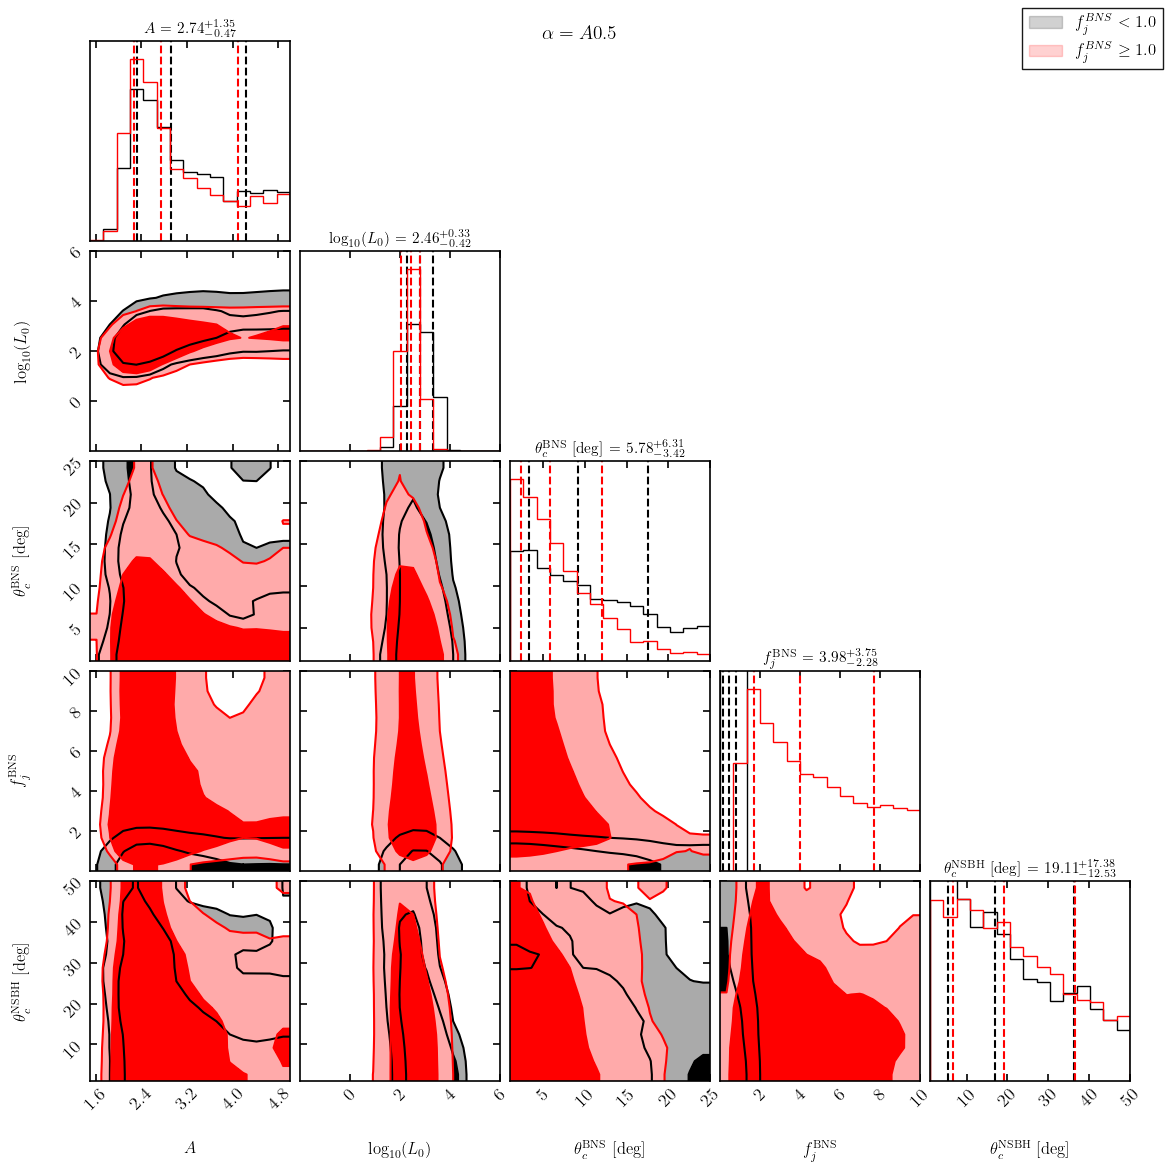

Loading existing directory  : Output_files/midpoint_complete_alpha_A1.0


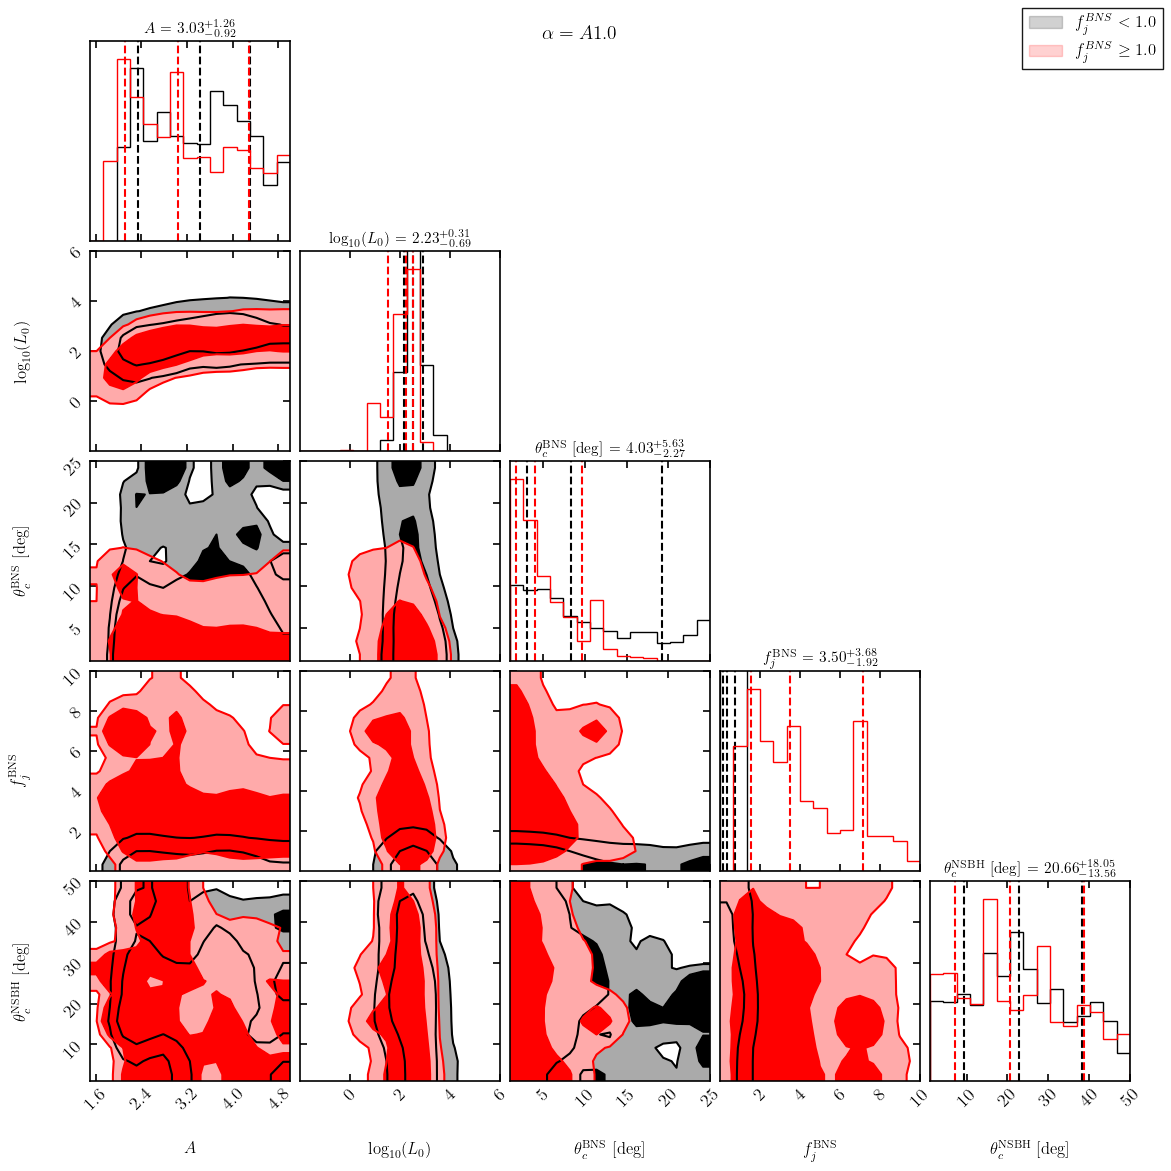

Loading existing directory  : Output_files/midpoint_complete_alpha_A3.0
Loading existing directory  : Output_files/midpoint_complete_alpha_A5.0


In [12]:
from mcmc_runner import plot_corner_cut

plot_corner_cut(
    alphas=possible_alpha,
    burn_frac=0.3,
    thin=20,
)

Plotting autocorrelation for alpha=A0.5


/home/ludo/.local/lib/python3.10/site-packages/emcee/autocorr.py:38: RuntimeWarning: invalid value encountered in divide
  acf /= acf[0]


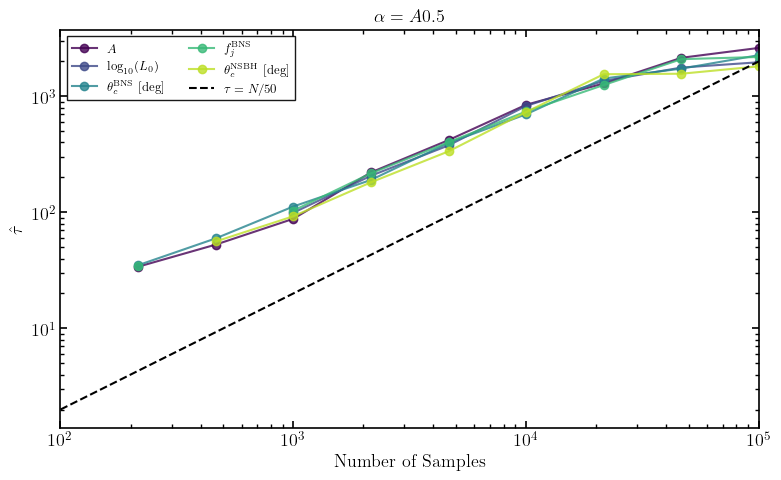

Plotting autocorrelation for alpha=A1.0


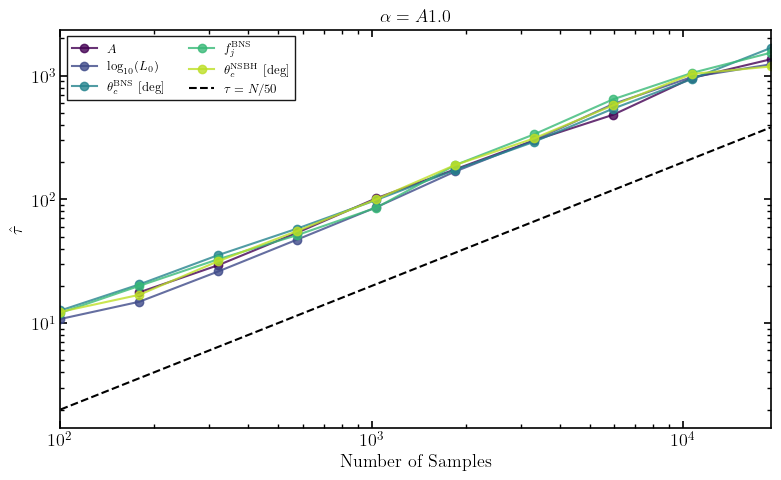

Plotting autocorrelation for alpha=A3.0


AttributeError: You must run the sampler with 'store == True' before accessing the results

In [13]:
import emcee
from mcmc_runner import labels as param_labels

def plot_alpha_autocorrelation(alpha, backend_path, labels, c=5.0, filename=None, close=True):
    chain = emcee.backends.HDFBackend(backend_path).get_chain()
    n_steps, _, n_params = chain.shape
    n_params = len(labels)
    n_vals = np.unique(np.clip(np.exp(np.linspace(np.log(100), np.log(n_steps), 10)).astype(int), 100, n_steps))

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, n_params))

    for i in range(n_params):
        tau = [np.mean(emcee.autocorr.integrated_time(chain[:n, :, i], c=c, tol=0, quiet=True)) for n in n_vals]
        ax.loglog(n_vals, tau, 'o-', color=colors[i], label=labels[i], alpha=0.8)

    ax.plot(n_vals, n_vals / 50, '--k', lw=1.5, label=r'$\tau = N/50$')
    ax.set(xlabel='Number of Samples', ylabel=r'$\hat{\tau}$', xlim=(100, n_steps))
    ax.set_title(rf'$\alpha = {alpha}$')
    ax.legend(fontsize=9, ncol=2)

    fig.tight_layout()
    if filename is None:
        filename = f'autocorrelation_{alpha}.pdf'
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    if close:
        plt.close(fig)
    return fig

for alpha in possible_alpha:
    print(f'Plotting autocorrelation for alpha={alpha}')
    # not for baseline but for the new runs, which are more relevant for convergence diagnostics
    path = Path(f"Output_files/midpoint_complete_alpha_{alpha}/emcee.h5")
    plot_alpha_autocorrelation(alpha, path, param_labels)